In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib Inline
%config InlineBackend.figure_format="svg"

## Lab tasks
### The Validation Set Approach

We explore the use of the validation set approach in order to estimate the
test error rates that result from fitting various linear models on the Auto
data set.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
auto = pd.read_csv("data/Auto.csv")
auto["horsepower"] = pd.to_numeric(auto["horsepower"].replace("?", np.nan))
auto = auto.dropna().reset_index(drop=True)

In [6]:
X = auto[["horsepower"]]
Y = auto[["mpg"]]

def evaluate_polynomials(X, y, random_state):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=random_state)
    
    mses = {}
    
    for degree in [1, 2, 3]:
        if degree == 1:
            model = LinearRegression()
            model.fit(X_train, y_train)
            preds = model.predict(X_val)
        else:
            poly = PolynomialFeatures(degree=degree, include_bias=False)
            X_train_poly = poly.fit_transform(X_train)
            X_val_poly = poly.transform(X_val)
            
            model = LinearRegression()
            model.fit(X_train_poly, y_train)
            preds = model.predict(X_val_poly)
            
        mses[degree] = mean_squared_error(y_val, preds)
        
    return mses

In [14]:
print("=== Experiment 1 ===")
exp_1_results = evaluate_polynomials(X=X, y=Y, random_state=1)
print("In this case we have chosen random seed = 1. \nThe information below showes the result of fitting the Linear Regression "
"using different values of polynoms\n")
for pol, mse in exp_1_results.items():
    print(f"Linear regression with polynom {pol} get MSE: {mse}")

=== Experiment 1 ===
In this case we have chosen random seed = 1. 
The information below showes the result of fitting the Linear Regression using different values of polynoms

Linear regression with polynom 1 get MSE: 24.80212062059356
Linear regression with polynom 2 get MSE: 18.848292603275663
Linear regression with polynom 3 get MSE: 18.805111358605235


In [18]:
print("=== Experiment 2 ===")
exp_1_results = evaluate_polynomials(X=X, y=Y, random_state=10)
print("In this case we have chosen random seed = 10. \nThe information below showes the result of fitting the Linear Regression "
"using different values of polynoms\n")
for pol, mse in exp_1_results.items():
    print(f"Linear regression with polynom {pol} get MSE: {mse}")

=== Experiment 2 ===
In this case we have chosen random seed = 10. 
The information below showes the result of fitting the Linear Regression using different values of polynoms

Linear regression with polynom 1 get MSE: 23.06058834250622
Linear regression with polynom 2 get MSE: 19.717794109923414
Linear regression with polynom 3 get MSE: 19.708416156919125


As we can see, a more flexible method turned out to be a better choice for predicting mpg based on horsepower. The quadratic and cubic models (degrees 2 and 3) showed better results (around 19.7) compared to simple linear regression (23.06). The flexibility of the higher-degree models is sufficient to capture the underlying patterns without overfitting, even though we used only a single feature

The main conclusion is that the Validation Set approach heavily depends on which observations are selected for the validation set. When the random seed was set to 1, the results were 24.8, 18.8, and 18.8. Changing the random state to 10 caused the results to change significantly. While this approach provides a good opportunity to test our model using a holdout sample, it still suffers from high variance. The fact that changing the random state alters the results so much clearly demonstrates this instability

### Leave-One-Out Cross-Validation

In [19]:
from sklearn.model_selection import LeaveOneOut, cross_val_score

In [23]:
X = auto[["horsepower"]]
y = auto[["mpg"]]

loo = LeaveOneOut()
cv_errors = []

for i in range(1, 6):
    if i == 1:
        model = LinearRegression()
        scores = cross_val_score(model, X, y, cv=loo, scoring="neg_mean_squared_error")
    else:
        poly = PolynomialFeatures(degree=i, include_bias=False)
        X_poly = poly.fit_transform(X)
        
        model = LinearRegression()
        scores = cross_val_score(model, X_poly, y, cv=loo, scoring="neg_mean_squared_error")
    
    mean_mse = -np.mean(scores)
    cv_errors.append(mean_mse)
    print(f"polynomials of degree {i} | LOOCV MSE: {mean_mse:.4f}")

print("\nThe result vector:")
print(cv_errors)

polynomials of degree 1 | LOOCV MSE: 24.2315
polynomials of degree 2 | LOOCV MSE: 19.2482
polynomials of degree 3 | LOOCV MSE: 19.3350
polynomials of degree 4 | LOOCV MSE: 19.4244
polynomials of degree 5 | LOOCV MSE: 19.0332

The result vector:
[np.float64(24.23151351792922), np.float64(19.248213124489684), np.float64(19.334984064029346), np.float64(19.424430310350626), np.float64(19.0332122147925)]


Once again, the more flexible model won the competition. Now we can be sure that the relationship between mpg and horsepower is quadratic. The evidence for this conclusion is the dramatic decrease in MSE (by 5 units).

LOOCV allows us to perform quite accurate testing of our model's predictions without relying on a single validation split. This time, the evaluation does not depend on random sampling because we use $n-1$ observations for training each time. If we restart the fitting process, we will not observe any changes. Yet, LOOCV still has high variance because it uses almost the same training set each time,therefore, there is a high correlation between the estimated models, hence increasing the overall variance

### Leave-One-Out Cross-Validation

In [25]:
from sklearn.model_selection import KFold

In [27]:
X = auto[["horsepower"]]
y = auto[["mpg"]]

kf = KFold(n_splits=10, random_state=17, shuffle=True)
cv_errors_10 = []

for i in range(1, 11):
    if i == 1:
        model = LinearRegression()
        scores = cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error")
    else:
        poly = PolynomialFeatures(degree=i, include_bias=False)
        X_poly = poly.fit_transform(X)
        
        model = LinearRegression()
        scores = cross_val_score(model, X_poly, y, cv=kf, scoring="neg_mean_squared_error")
        
    mean_mse = -np.mean(scores)
    cv_errors_10.append(mean_mse)
    print(f"polynomials of degree {i} | 10-fold MSE: {mean_mse:.4f}")

polynomials of degree 1 | 10-fold MSE: 24.1823
polynomials of degree 2 | 10-fold MSE: 19.1376
polynomials of degree 3 | 10-fold MSE: 19.1552
polynomials of degree 4 | 10-fold MSE: 19.2502
polynomials of degree 5 | 10-fold MSE: 18.8971
polynomials of degree 6 | 10-fold MSE: 19.0255
polynomials of degree 7 | 10-fold MSE: 18.9791
polynomials of degree 8 | 10-fold MSE: 18.8582
polynomials of degree 9 | 10-fold MSE: 19.0099
polynomials of degree 10 | 10-fold MSE: 19.7377


This case clearly demonstrates the fact that an increase in model flexibility does not always lead to better results. The polynomial of degree 2 significantly decreased the test error, but higher-order polynomials did not make a big difference and hovered around the same level.

The main conclusion is that the k-fold approach takes less time for fitting due to the smaller number of training iterations. Also, this approach manages to find a good balance between variance and bias. It uses different groups of observations and, at the same time, does not introduce high correlation between the models

### The Bootstrap

In [28]:
portfolio = pd.read_csv("data/Portfolio.csv")

In [35]:
def alpha_fn(data, index):
    df = data.loc[index]
    X = df["X"]
    Y = df["Y"]
    
    cov_matrix = np.cov(X, Y)
    var_X = cov_matrix[0, 0]
    var_Y = cov_matrix[1, 1]
    cov_XY = cov_matrix[0, 1]
    
    return (var_Y - cov_XY) / (var_X + var_Y - 2 * cov_XY)

In [33]:
print("Origin Alpha:", alpha_fn(portfolio, portfolio.index))

Origin Alpha: 0.5758320745928298


In [34]:
bootstrap_1 = np.random.choice(portfolio.index, size=100, replace=True)
print("1 Bootstrap Alpha:", alpha_fn(portfolio, bootstrap_1))

1 Bootstrap Alpha: 0.618716274297488


The results for these two samples are quite different. In order to obtain a reliable bootstrap estimate (or standard error), we need to generate a large number of bootstrap replicates (e.g., $B = 1000$)

In [37]:
np.random.seed(1)

B = 1000
bootstrap_alphas = []

for b in range(B):
    current_b = np.random.choice(portfolio.index, replace=True, size=100)
    
    alpha = alpha_fn(portfolio, current_b)
    bootstrap_alphas.append(alpha)

bootstrap_alphas = np.array(bootstrap_alphas)
se_alpha = np.std(bootstrap_alphas, ddof=1)
mean_alpha = np.mean(bootstrap_alphas)

print(f"Mean alpha is {mean_alpha}")
print(f"Standard Error alpha is {se_alpha}")
print(f"Mean alpha is {mean_alpha}")

Mean alpha is 0.5784905227103104
Standard Error alpha is 0.09296141702441607
Mean alpha is 0.5784905227103104


Based on these calculations, we can draw the following conclusions:
- The results obtained via the bootstrap method are remarkably close to the original estimate
- The Standard Error is quite low (0.0930), which implies that our alpha estimate is stable and trustworthy; this metric is unlikely to fluctuate significantly across different samples
- The bootstrap mean alpha is almost identical to the original value

The bootstrap approach successfully produced an accurate estimate and demonstrated that this allocation ratio can be reliably used for investment decisions 

In [41]:
def boot_fn(data, index):
    df = data.loc[index]
    X_boot = df[["horsepower"]]
    y_boot = df["mpg"]
    
    model = LinearRegression()
    model.fit(X_boot, y_boot)
    
    return model.intercept_, model.coef_[0]


b0_orig, b1_orig = boot_fn(auto, auto.index)
print(f"Original Coefficients:\nIntercept (Beta_0): {b0_orig:.4f}\nHorsepower (Beta_1): {b1_orig:.4f}\n")

beta_0 = []
beta_1 = []

for b in range(B):
    current_b = np.random.choice(auto.index, replace=True, size=auto.shape[0])
    
    intercept, coef_0 = boot_fn(auto, current_b)
    beta_0.append(intercept)
    beta_1.append(coef_0)

print("beta_0 mean:", np.mean(beta_0))
print("beta_1 mean:", np.mean(beta_1))

print("\nbeta_0 Standard Error:", np.std(beta_0, ddof=1))
print("beta_1 Standard Error:", np.std(beta_1, ddof=1))

Original Coefficients:
Intercept (Beta_0): 39.9359
Horsepower (Beta_1): -0.1578

beta_0 mean: 39.89422508142119
beta_1 mean: -0.15747040471628057

beta_0 Standard Error: 0.8104833010447667
beta_1 Standard Error: 0.00689344114483501


To sum up, the mean values for the computed coefficients are noticeably close to the original weights. The standard errors are quite low, although the standard error for $\beta_1$ is much smaller

In [48]:
1 / np.pow(5,5)

np.float64(0.00032)

In [65]:
1 - (1 - 1 / 100) ** 100

0.6339676587267709

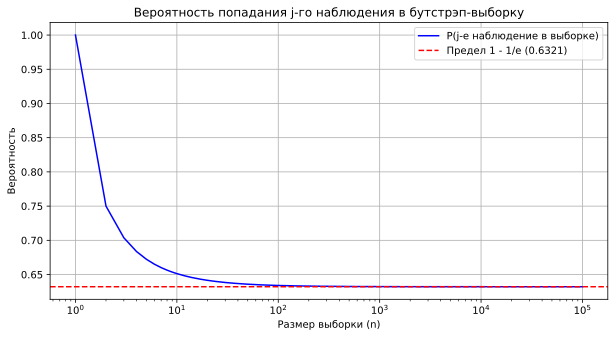

In [64]:
n_values = np.logspace(0, 5, 500, dtype=int) 

# Считаем вероятности по нашей формуле
probabilities = 1 - (1 - 1 / n_values) ** n_values

# Строим график
plt.figure(figsize=(10, 5))
plt.plot(n_values, probabilities, label='P(j-е наблюдение в выборке)', color='blue')
plt.axhline(y=1 - 1/np.e, color='red', linestyle='--', label=f'Предел 1 - 1/e ({1 - 1/np.e:.4f})')
plt.xscale('log') # Используем логарифмическую шкалу для наглядности
plt.xlabel('Размер выборки (n)')
plt.ylabel('Вероятность')
plt.title('Вероятность попадания j-го наблюдения в бутстрэп-выборку')
plt.grid(True)
plt.legend()
plt.show()

## Block Applied

### 5. TASK

In Chapter 4, we used logistic regression to predict the probability of
default using income and balance on the Default data set. We will
now estimate the test error of this logistic regression model using the
validation set approach. Do not forget to set a random seed before
beginning your analysis.

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

(a) Fit a logistic regression model that uses income and balance to
predict default.

(b) Using the validation set approach, estimate the test error of this
model. In order to do this, you must perform the following steps:
- Split the sample set into a training set and a validation set.
- Fit a multiple logistic regression model using only the training observations.
- Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.
- Compute the validation set error, which is the fraction of
the observations in the validation set that are misclassified.

In [82]:
default = pd.read_csv("data/Default.csv")
default["default_bi"] = default["default"].map({"Yes": 1, "No": 0})

X = default[["balance", "income"]]
y = default["default_bi"]


def calc_validation_error(seed, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=seed)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_valid_scaled = scaler.transform(X_val)

    lr = LogisticRegression(random_state=seed)
    lr.fit(X_train_scaled, y_train)
    y_preds = lr.predict(X_valid_scaled)

    validation_error = accuracy_score(y_val, y_preds)

    return validation_error

validation_error = calc_validation_error(seed=42, X=X, y=y)
print("Validation Error Rate is", 1 - validation_error)

Validation Error Rate is 0.027599999999999958


(c) Repeat the process in (b) three times, using three different splits
of the observations into a training set and a validation set. Comment on the results obtained.

In [83]:
randoms_states = [60, 72, 10]

for state in randoms_states:

    validation_error = calc_validation_error(seed=state, X=X, y=y)
    print("Random_state =", state)
    print("Validation Error Rate is", 1 - validation_error)

Random_state = 60
Validation Error Rate is 0.026000000000000023
Random_state = 72
Validation Error Rate is 0.023599999999999954
Random_state = 10
Validation Error Rate is 0.030000000000000027


Based on the calculations above, we can draw the following conclusion: the final validation error rate depends heavily on the specific validation split. For instance, with random_state=60 the error is 0.0260, with random_state=72 it drops to 0.0236, and with random_state=10 it increases to 0.0300

(d) Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a
dummy variable for student leads to a reduction in the test error
rate.

In [84]:
default["student_new"] = default["student"].map({"Yes": 1, "No": 0})

X = default[["income", "balance", "student_new"]]
y = default["default_bi"]

validation_error = calc_validation_error(seed=42, X=X, y=y)
print("Random_state =", 42)
print("Validation Error Rate is", 1 - validation_error)

Random_state = 42
Validation Error Rate is 0.027599999999999958


The addition of the dummy variable for students did not change the validation error rate. The value remained identical. We should also note that this comparison was made using the exact same random_state